# **Capstone Project**

## **Research Goal:**


### **Research Objectives:**


### **Dataset Choice:**

  ### [Twin-2K-500 Dataset](https://huggingface.co/datasets/LLM-Digital-Twin/Twin-2K-500)

  This dataset Twin-2K-500 contains comprehensive persona information from a representative sample of 2,058 US participants, providing rich demographic and psychological data. The dataset is specifically designed for building digital twins for LLM simulations.

## EDA Objectives

1. **Clean & parse** nested persona JSON into usable dataframes  

2. **Persona analytics**: demographics + psychology + geography + culture  

3. **Clustering & selection**: KMeans-based cohort selection + validation plots

## **1. Clean and Construct a Dataframe**


*   Aids towards analysis and visulisation of the data.


### 1A.  Import and Installing the Libraries

In [1]:
!pip -q install -U huggingface_hub datasets pandas numpy matplotlib seaborn scikit-learn folium SciencePlots plotly

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.51.3 requires huggingface-hub<1.0,>=0.30.0, but you have huggingface-hub 1.7.2 which is incompatible.
tokenizers 0.21.1 requires huggingface-hub<1.0,>=0.16.4, but you have huggingface-hub 1.7.2 which is incompatible.


In [2]:
import os
import json
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pprint import pprint
from IPython.display import display

from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import folium

# Plot styling for readable notebook figures
sns.set_context("talk")
sns.set_style("whitegrid")

# Scienceplots styles (nice paper-like defaults)
import scienceplots
plt.style.use(["science", "no-latex"])

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


####  **Important things to note:**

i. Please generate a Hugging Face token as this is a massive dataset and I'm running the notebook from Hugging Face

```
!hf auth login
```

ii. Or you can save a secret in the Google Colab and run it as shown below



In [3]:
from huggingface_hub import login

hf_token = os.getenv("HF_TOKEN", None)
if hf_token:
    login(hf_token)

# --- Load dataset split/config ---
# "full_persona" contains persona_json blocks and persona_summary
ds = load_dataset("LLM-Digital-Twin/Twin-2K-500", "full_persona")

print(ds)
print("Split keys:", ds.keys())
print("Rows in ds['data']:", len(ds["data"]))

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


DatasetDict({
    data: Dataset({
        features: ['pid', 'persona_text', 'persona_summary', 'persona_json'],
        num_rows: 2058
    })
})
Split keys: dict_keys(['data'])
Rows in ds['data']: 2058


In [4]:
# Loading the dataset

first_blocks = json.loads(ds["data"][0]["persona_json"])

print("Type:", type(first_blocks))
print("Number of blocks:", len(first_blocks))
print("\nFirst block example:")
pprint(first_blocks[0])

Type: <class 'list'>
Number of blocks: 31

First block example:
{'BlockName': 'Demographics',
 'BlockType': 'Standard',
 'ElementType': 'Block',
 'Questions': [{'Answers': {'SelectedByPosition': 3,
                            'SelectedText': 'South (TX, OK, AR, LA, KY, TN, '
                                            'MS, AL, WV, DC, MD, DE, VA, NC, '
                                            'SC, GA, FL)'},
                'Options': ['Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME)',
                            'Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, MI, '
                            'IN, OH)',
                            'South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC, '
                            'MD, DE, VA, NC, SC, GA, FL)',
                            'West (WA, OR, ID, MT, WY, CA, NV, UT, CO, AZ, NM)',
                            'Pacific (HI, AK)'],
                'QuestionID': 'QID11',
                'QuestionText': 'Which part of the United States do you '
        

### 1B.  Flatten all the personas into a single dataframe:

Why:
- The raw data is nested: each person has multiple blocks, each block has multiple questions.
- For analysis (counts, distributions, filtering), we want a **tidy table**:
  one row per (pid, question).

Output:
- `df_questions`: question-level dataframe with columns like block_name, question_text, answers, etc.

In [5]:
data_split = ds["data"]

rows = []
bad = 0

for i in range(len(data_split)):
    try:
        r = data_split[i]
        pid = r["pid"]

        blocks = json.loads(r["persona_json"])

        # Normalize: sometimes could be dict; treat as single-block list
        if isinstance(blocks, dict):
            blocks = [blocks]

        for block in blocks:
            block_name = block.get("BlockName")
            block_type = block.get("BlockType")

            questions = block.get("Questions") or []  # None-safe

            for q in questions:
                rows.append({
                    "pid": pid,
                    "block_name": block_name,
                    "block_type": block_type,
                    "question_id": q.get("QuestionID"),
                    "question_text": q.get("QuestionText"),
                    "question_type": q.get("QuestionType"),
                    "answers": q.get("Answers"),
                    "options": q.get("Options"),
                })

    except Exception as e:
        bad += 1
        if bad <= 5:
            print(f"[WARN] Failed at index={i} pid={data_split[i].get('pid')} error={repr(e)}")

df_questions = pd.DataFrame(rows)

print(f"Flattened rows: {len(df_questions):,}")
print(f"Unique personas: {df_questions['pid'].nunique():,}")
display(df_questions.head(5))

Flattened rows: 485,641
Unique personas: 2,058


,pid,block_name,block_type,question_id,question_text,question_type,answers,options
0,574,Demographics,Standard,QID11,Which part of the United States do you current...,MC,"{'SelectedByPosition': 3, 'SelectedText': 'Sou...","[Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME..."
1,574,Demographics,Standard,QID12,What is the sex that you were assigned at birth?,MC,"{'SelectedByPosition': 1, 'SelectedText': 'Male'}","[Male, Female]"
2,574,Demographics,Standard,QID13,How old are you?,MC,"{'SelectedByPosition': 1, 'SelectedText': '18-...","[18-29, 30-49, 50-64, 65+]"
3,574,Demographics,Standard,QID14,What is the highest level of schooling or degr...,MC,"{'SelectedByPosition': 3, 'SelectedText': 'Som...","[Less than high school, High school graduate, ..."
4,574,Demographics,Standard,QID15,What is your race or origin?,MC,"{'SelectedByPosition': 1, 'SelectedText': 'Whi...","[White, Black, Asian, Hispanic, Other]"


### Quick EDA on question-level table

In [6]:
print("Columns:", df_questions.columns.tolist())

print("\nTop question types:")
display(df_questions["question_type"].value_counts().head(10))

print("\nTop blocks:")
display(df_questions["block_name"].value_counts().head(10))

# Preview one person's first few questions
one_pid = df_questions["pid"].iloc[0]
display(
    df_questions[df_questions["pid"] == one_pid][
        ["block_name", "question_id", "question_text", "question_type", "answers"]
    ].head(15)
)

print("\nUnique block names (survey sections):")
print(df_questions["block_name"].dropna().unique())

Columns: ['pid', 'block_name', 'block_type', 'question_id', 'question_text', 'question_type', 'answers', 'options']

Top question types:


question_type
MC        329273
Matrix     69972
TE         51410
DB         30870
Slider      4116
Name: count, dtype: int64


Top blocks:


block_name
Cognitive tests                            144052
Personality                                100842
Product Preferences - Pricing               84378
Economic preferences                        74054
Demographics                                28812
Non-experimental heuristics and biases      10290
Economic preferences - intro                 4116
Anchoring - African countries high           2112
Anchoring - redwood low                      2098
False consensus                              2058
Name: count, dtype: int64

,block_name,question_id,question_text,question_type,answers
0,Demographics,QID11,Which part of the United States do you current...,MC,"{'SelectedByPosition': 3, 'SelectedText': 'Sou..."
1,Demographics,QID12,What is the sex that you were assigned at birth?,MC,"{'SelectedByPosition': 1, 'SelectedText': 'Male'}"
2,Demographics,QID13,How old are you?,MC,"{'SelectedByPosition': 1, 'SelectedText': '18-..."
3,Demographics,QID14,What is the highest level of schooling or degr...,MC,"{'SelectedByPosition': 3, 'SelectedText': 'Som..."
4,Demographics,QID15,What is your race or origin?,MC,"{'SelectedByPosition': 1, 'SelectedText': 'Whi..."
5,Demographics,QID16,Are you a citizen of the United States?,MC,"{'SelectedByPosition': 1, 'SelectedText': 'Yes'}"
6,Demographics,QID17,Which of these best describes you?,MC,"{'SelectedByPosition': 6, 'SelectedText': 'Nev..."
7,Demographics,QID18,"What is your present religion, if any?",MC,"{'SelectedByPosition': 1, 'SelectedText': 'Pro..."
8,Demographics,QID19,"Aside from weddings and funerals, how often do...",MC,"{'SelectedByPosition': 3, 'SelectedText': 'Onc..."
9,Demographics,QID20,"In politics today, do you consider yourself a",MC,"{'SelectedByPosition': 1, 'SelectedText': 'Rep..."



Unique block names (survey sections):
<ArrowStringArray>
[                                   'Demographics',
                                    'Personality ',
                                'Cognitive tests ',
                   'Economic preferences - intro ',
                           'Economic preferences ',
                                    'Forward Flow',
                                'False consensus ',
                          'Base-rate 70 engineers',
                                    'Disease-loss',
                               'Linda-conjunction',
                         'Outcome bias - success ',
              'Anchoring - African countries low ',
                         'Anchoring - redwood low',
                          'Less is More Gamble C ',
                         'Proportion dominance 1C',
                         'Proportion dominance 2C',
                                 'Sunk cost - yes',
                  'Absolute vs. relative - jacket',
      

**Insights:**

*   We are not interested in the entire dataset, just the important categories and their respective arttributes such as demography, cognitive tests and socio-economic tests.


*   We will leverage the user persona summary column from this dataset to help us out to do some simple regex expressions and clean the data





### 1C. Use persona_summary to build a persona-level dataframe

Why:
- `persona_json` is great for question-level analysis, but harder for population-level analytics.
- `persona_summary` contains:
  - demographics (Age, Race, Education, etc.)
  - trait scores (Big Five + other measures)
  - percentiles for traits

We will parse `persona_summary` with regex into a **persona-level table**:
one row per pid, columns = demographics + scores + percentiles.

####    Regex + parsing function 

In [7]:
# Matches lines like: score_openness = 0.12 (53rd percentile)
SCORE_RE = re.compile(
    r"(?P<key>[A-Za-z_][A-Za-z0-9_\-]*)\s*=\s*(?P<val>[-+]?\d*\.?\d+)\s*\((?P<pct>\d+)(?:st|nd|rd|th)\s+percentile\)",
    flags=re.IGNORECASE,
)

# Matches demographic lines like: Age : 30-49
DEM_RE = re.compile(
    r"^\s*(?P<field>[A-Za-z][A-Za-z /()-]+?)\s*:\s*(?P<value>.+?)\s*$",
    flags=re.MULTILINE,
)

def parse_persona_summary(text: str):
    """
    Parse persona_summary string into:
      - scores: {key -> float}
      - percentiles: {key_pct -> int}
      - demographics: {field -> str}

    Notes:
    - We only parse demographics inside the demographics section to avoid accidental matches.
    - Regex parsing is brittle if the dataset format changes, but works well for this dataset.
    """
    if text is None:
        return {}, {}, {}

    scores = {}
    percentiles = {}

    # 1) Extract score variables + percentile ranks
    for m in SCORE_RE.finditer(text):
        key = m.group("key").strip()
        val = float(m.group("val"))
        pct = int(m.group("pct"))
        scores[key] = val
        percentiles[f"{key}_pct"] = pct

    # 2) Extract demographics (only from the demographics section if present)
    demographics = {}

    if "The person's demographics" in text:
        # Grab text after the demographics header
        chunk = text.split("The person's demographics are the following", 1)[-1]

        # Stop at the start of the next section(s)
        for stop in ["The person's Big 5", "The person's Big 5 scores"]:
            if stop in chunk:
                chunk = chunk.split(stop, 1)[0]

        # Parse each "Field : Value" line
        for m in DEM_RE.finditer(chunk):
            field = m.group("field").strip()
            value = m.group("value").strip()

            # Heuristic filtering to avoid capturing long narrative sentences
            if len(field) <= 40 and len(value) <= 200:
                demographics[field] = value

    return scores, percentiles, demographics

In [8]:
# Build persona-level dataframe (persona_df)

persona_rows = []

for r in ds["data"]:
    pid = r["pid"]
    summary = r.get("persona_summary", None)

    scores, pcts, demos = parse_persona_summary(summary)

    row = {"pid": pid}
    row.update(demos)
    row.update(scores)
    row.update(pcts)

    persona_rows.append(row)

persona_df = pd.DataFrame(persona_rows).set_index("pid")

print("persona_df shape:", persona_df.shape)
display(persona_df.head())
print("\nNumber of columns:", len(persona_df.columns))

persona_df shape: (2058, 110)


,Geographic region,Gender,Age,Education level,Race,Citizen of the US,Marital status,Religion,Religious attendance,Political affiliation,...,score_RFS_pct,score_ST-TW_pct,score_depression_pct,score_CNFU-S_pct,score_selfmonitor_pct,score_SCC_pct,score_needforclosure_pct,score_maximization_pct,score_wason_pct,score_dictator_sender_pct
pid,,,,,,,,,,,,,,,,,,,,,
574,"South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC,...",Male,18-29,"Some college, no degree",White,Yes,Never been married,Protestant,Once or twice a month,Republican,...,81,57,9,61,58,50,75,64,96,81
2001,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, M...",Female,50-64,College graduate/some postgrad,White,Yes,Married,Nothing in particular,Seldom,Democrat,...,53,62,54,43,58,63,16,45,96,81
1710,"South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC,...",Female,50-64,Postgraduate,White,Yes,Married,Protestant,Once or twice a month,Republican,...,5,80,85,72,33,20,21,34,65,18
1277,"West (WA, OR, ID, MT, WY, CA, NV, UT, CO, AZ, NM)",Female,30-49,Associate's degree,White,Yes,Separated,Other,Never,Independent,...,41,57,92,75,46,11,54,92,65,81
789,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, M...",Female,50-64,High school graduate,Black,Yes,Never been married,Other,Seldom,Republican,...,2,18,54,23,3,100,21,1,96,81



Number of columns: 110


In [9]:
# Data-quality EDA for persona_df (missingness, types)

print("Shape:", persona_df.shape)

print("\nDtypes (first 30):")
display(persona_df.dtypes.head(30))

missing = persona_df.isna().mean().sort_values(ascending=False)
print("\nTop 20 missing columns:")
display(missing.head(20))

print("\nColumns with <5% missing (good coverage):", (missing < 0.05).sum())
print("Columns with >50% missing (sparse):", (missing > 0.50).sum())

print("\nUnique values (top 20):")
display(persona_df.nunique().sort_values(ascending=False).head(20))

Shape: (2058, 110)

Dtypes (first 30):


Geographic region                    str
Gender                               str
Age                                  str
Education level                      str
Race                                 str
Citizen of the US                    str
Marital status                       str
Religion                             str
Religious attendance                 str
Political affiliation                str
Income                               str
Political views                      str
Household size                       str
Employment status                    str
score_extraversion               float64
score_agreeableness              float64
wave1_score_conscientiousness    float64
score_openness                   float64
score_neuroticism                float64
score_needforcognition           float64
score_agency                     float64
score_communion                  float64
score_minimalism                 float64
score_BES                        float64
score_GREEN     


Top 20 missing columns:


score_lossaversion            0.677357
score_lossaversion_pct        0.677357
score_riskaversion_pct        0.113217
score_riskaversion            0.113217
score_presentbias_pct         0.093294
score_discount_pct            0.093294
score_discount                0.093294
score_presentbias             0.093294
score_forwardflow             0.000486
score_forwardflow_pct         0.000486
score_GREEN_pct               0.000000
crt2_score_pct                0.000000
score_agency_pct              0.000000
score_fluid_pct               0.000000
score_crystallized_pct        0.000000
score_syllogism_merged_pct    0.000000
score_BES_pct                 0.000000
score_actual_total_pct        0.000000
score_minimalism_pct          0.000000
score_communion_pct           0.000000
dtype: float64


Columns with <5% missing (good coverage): 102
Columns with >50% missing (sparse): 2

Unique values (top 20):


score_presentbias             394
score_lossaversion            333
score_discount                321
score_forwardflow             256
score_riskaversion            180
score_agency                  112
score_forwardflow_pct         101
score_communion                94
score_lossaversion_pct         86
score_trustgame_receiver       86
score_riskaversion_pct         78
score_needforcognition         73
score_presentbias_pct          66
score_BES                      65
score_overplacement            61
score_agency_pct               60
score_needforcognition_pct     58
score_needforclosure           58
score_discount_pct             57
score_RFS                      53
dtype: int64

In [10]:
print(f"All the cols: {persona_df.columns.to_list()}")

All the cols: ['Geographic region', 'Gender', 'Age', 'Education level', 'Race', 'Citizen of the US', 'Marital status', 'Religion', 'Religious attendance', 'Political affiliation', 'Income', 'Political views', 'Household size', 'Employment status', 'score_extraversion', 'score_agreeableness', 'wave1_score_conscientiousness', 'score_openness', 'score_neuroticism', 'score_needforcognition', 'score_agency', 'score_communion', 'score_minimalism', 'score_BES', 'score_GREEN', 'crt2_score', 'score_fluid', 'score_crystallized', 'score_syllogism_merged', 'score_actual_total', 'score_overconfidence', 'score_overplacement', 'score_ultimatum_sender', 'score_ultimatum_accepted', 'score_mentalaccounting', 'score_socialdesirability', 'wave2_score_conscientiousness', 'score_anxiety', 'score_HI', 'score_HC', 'score_VI', 'score_VC', 'score_finliteracy', 'score_numeracy', 'score_deductive_certainty', 'score_forwardflow', 'score_discount', 'score_presentbias', 'score_riskaversion', 'score_lossaversion', 's

*We form this cleaned dataset with the choices*

```
persona_df
```



## **2. Persona-level Analytics:**



*   Conducting a comprehensive analysis of the cleaned dataset.
*   It is a population-level analysis


###     2A. Psychological Analytics (Population)

We start with personality and cognitive traits:

- Big Five trait distributions
- Trait relationships (pairplot, correlation heatmap)
- Cognitive Reflection Test (CRT) distribution
- Risk aversion distribution
- Bias proxy exploration (overconfidence, overplacement, etc.)
- Test–retest reliability (wave1 vs wave2 where available)

- Big 5 trait distributions (population-level)

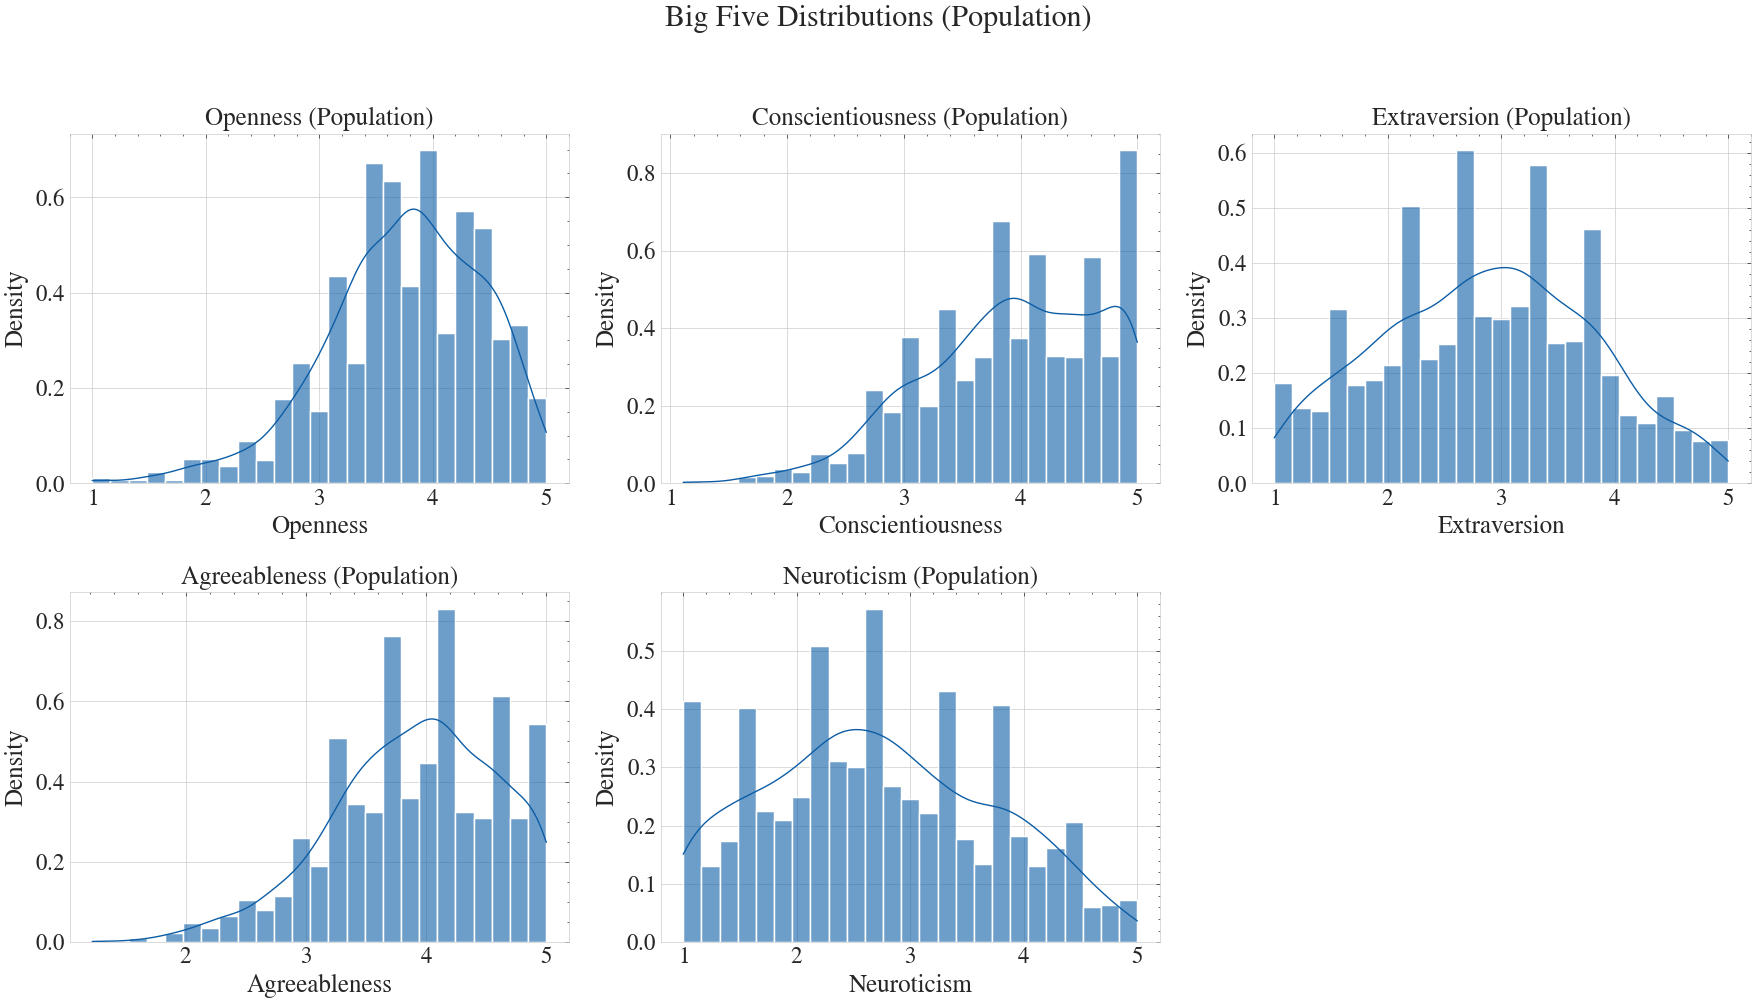

In [11]:
BIG5_TRAITS = {
    "Openness": "score_openness",
    "Conscientiousness": "wave1_score_conscientiousness",
    "Extraversion": "score_extraversion",
    "Agreeableness": "score_agreeableness",
    "Neuroticism": "score_neuroticism",
}

# Keep only cols that exist in the dataframe
big5_cols = [col for col in BIG5_TRAITS.values() if col in persona_df.columns]

big5 = persona_df[big5_cols].copy()
big5 = big5.rename(columns={v: k for k, v in BIG5_TRAITS.items() if v in big5_cols})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, trait in enumerate(big5.columns):
    sns.histplot(
        big5[trait].dropna(),
        bins=25,
        kde=True,
        stat="density",
        alpha=0.6,
        ax=axes[i],
    )
    axes[i].set_title(f"{trait} (Population)")
    axes[i].set_xlabel(trait)
    axes[i].set_ylabel("Density")

# Turn off the unused subplot (2x3 grid but 5 traits)
axes[-1].axis("off")

plt.suptitle("Big Five Distributions (Population)", y=1.02)
plt.tight_layout()
plt.show()

-   Pairplot + correlation heatmap


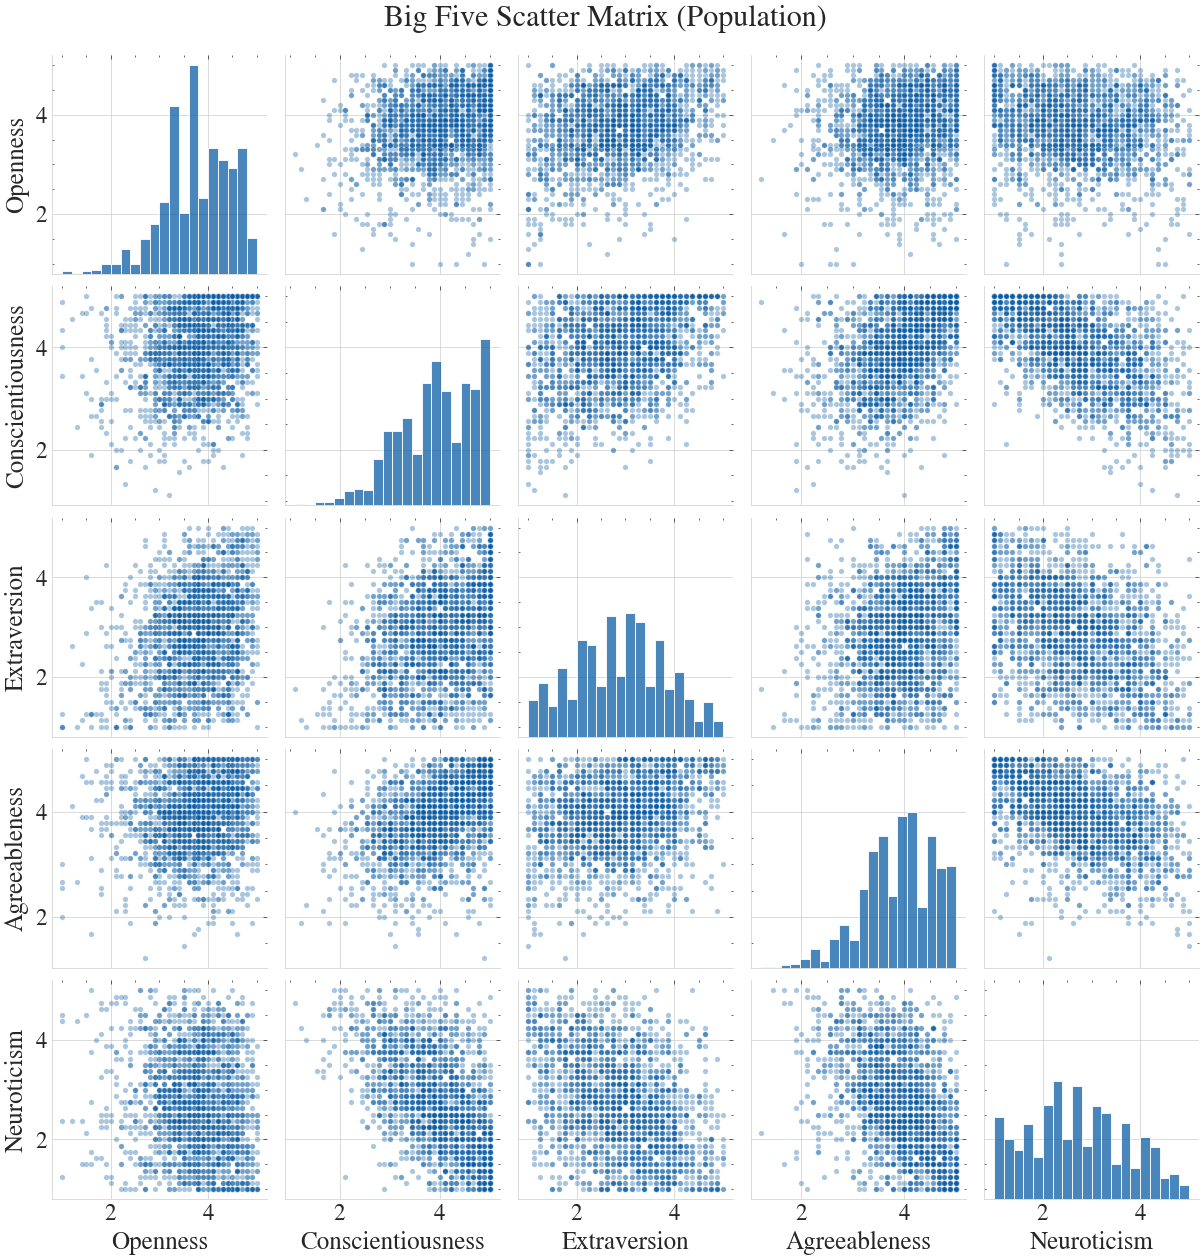

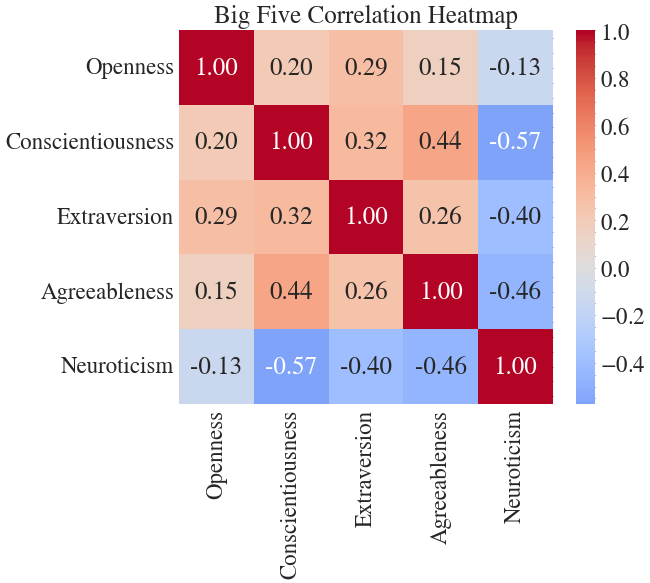

In [12]:

pair_df = big5.dropna()

if len(pair_df) > 0 and pair_df.shape[1] >= 2:
    sns.pairplot(
        pair_df,
        vars=list(pair_df.columns),
        diag_kind="hist",
        plot_kws={"alpha": 0.35, "s": 15},
        diag_kws={"bins": 20},
    )
    plt.suptitle("Big Five Scatter Matrix (Population)", y=1.02)
    plt.show()

    plt.figure(figsize=(7, 6))
    sns.heatmap(pair_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Big Five Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough complete Big Five rows to compute pairplot/correlation.")

-   CRT + risk distributions

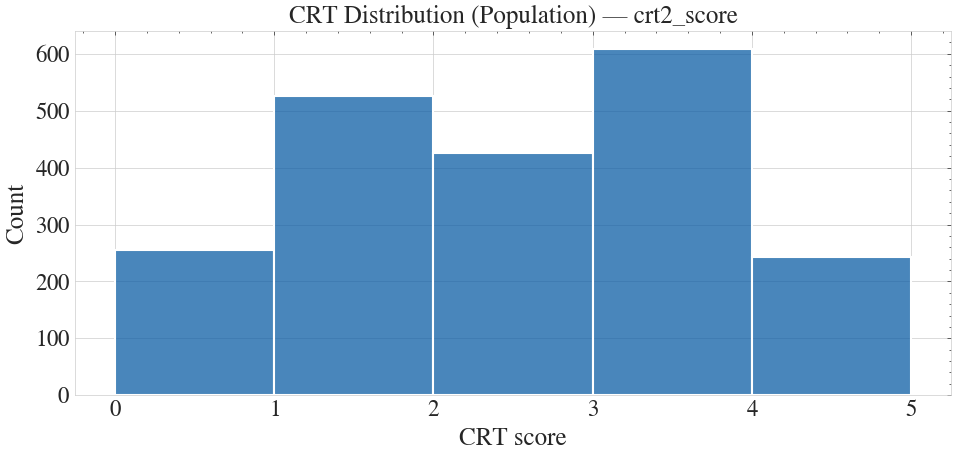

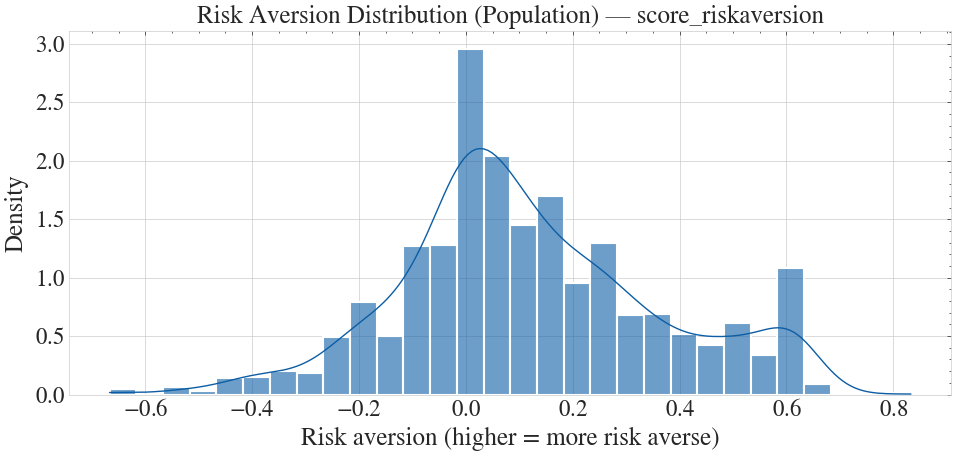

In [13]:
# CRT + risk distributions

CRT_KEY = "crt2_score"
RISK_KEY = "score_riskaversion"

if CRT_KEY in persona_df.columns:
    crt = persona_df[CRT_KEY].dropna()
    plt.figure(figsize=(10, 5))
    if len(crt) > 0:
        sns.histplot(crt, bins=range(int(crt.min()), int(crt.max()) + 2))
        plt.title(f"CRT Distribution (Population) — {CRT_KEY}")
        plt.xlabel("CRT score")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
    else:
        print("CRT column exists but has no non-null values.")
else:
    print(f"{CRT_KEY} not found in persona_df.")

if RISK_KEY in persona_df.columns:
    risk = persona_df[RISK_KEY].dropna()
    plt.figure(figsize=(10, 5))
    if len(risk) > 0:
        sns.histplot(risk, bins=30, kde=True, stat="density", alpha=0.6)
        plt.title(f"Risk Aversion Distribution (Population) — {RISK_KEY}")
        plt.xlabel("Risk aversion (higher = more risk averse)")
        plt.ylabel("Density")
        plt.tight_layout()
        plt.show()
    else:
        print("Risk column exists but has no non-null values.")
else:
    print(f"{RISK_KEY} not found in persona_df.")

- Bias columns discovery + distributions + correlation heatmap

Bias-related columns found: 14
First 40: ['score_lossaversion', 'score_lossaversion_pct', 'score_maximization', 'score_maximization_pct', 'score_mentalaccounting', 'score_mentalaccounting_pct', 'score_numeracy', 'score_numeracy_pct', 'score_overconfidence', 'score_overconfidence_pct', 'score_overplacement', 'score_overplacement_pct', 'score_riskaversion', 'score_riskaversion_pct']


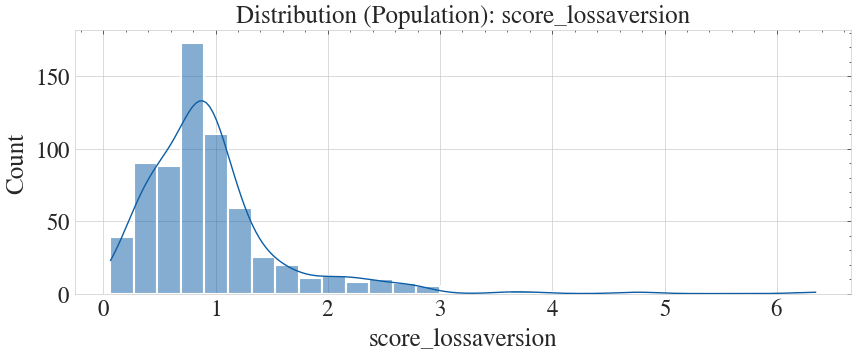

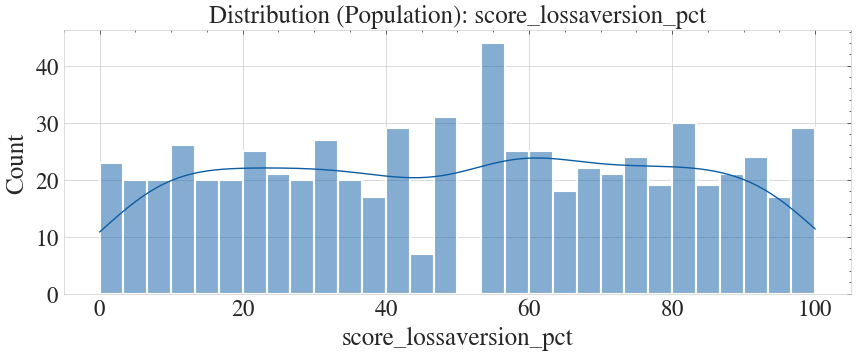

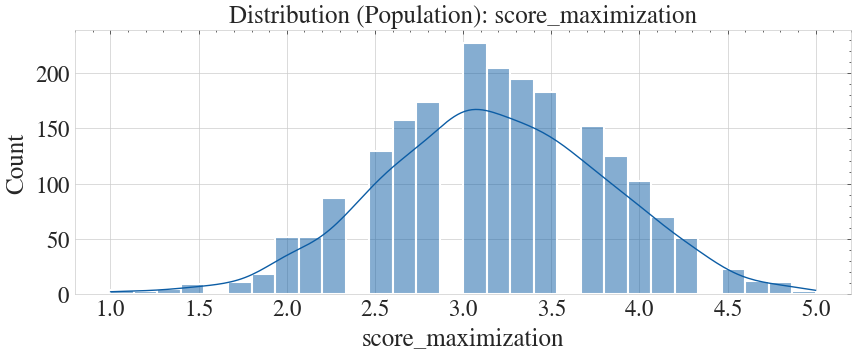

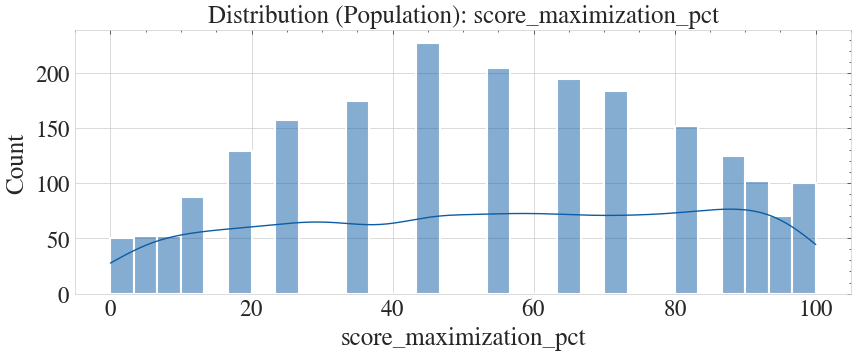

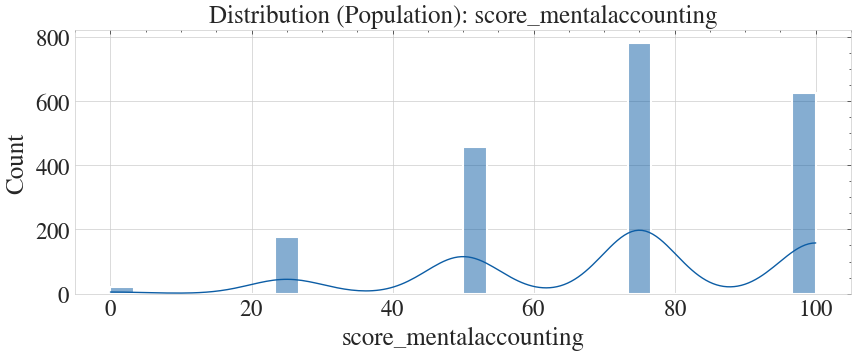

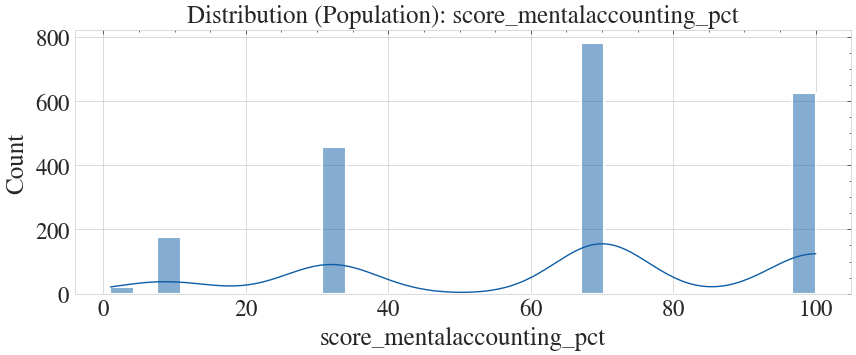

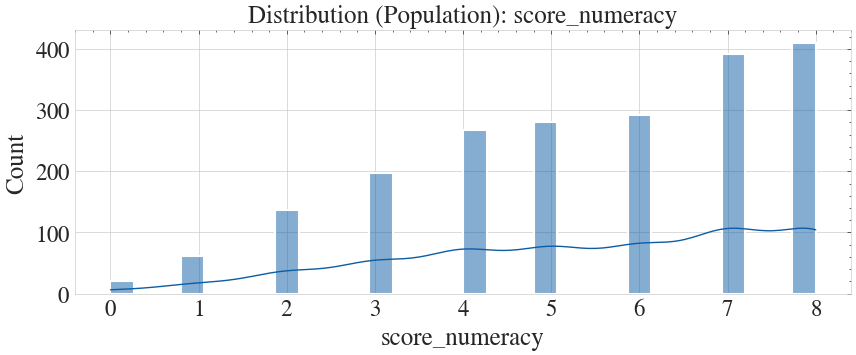

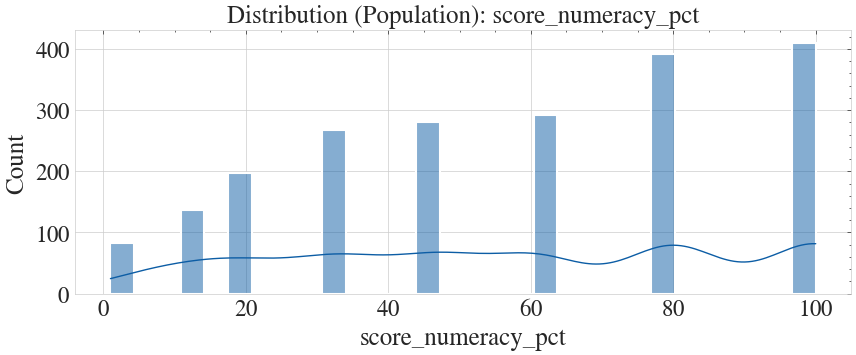

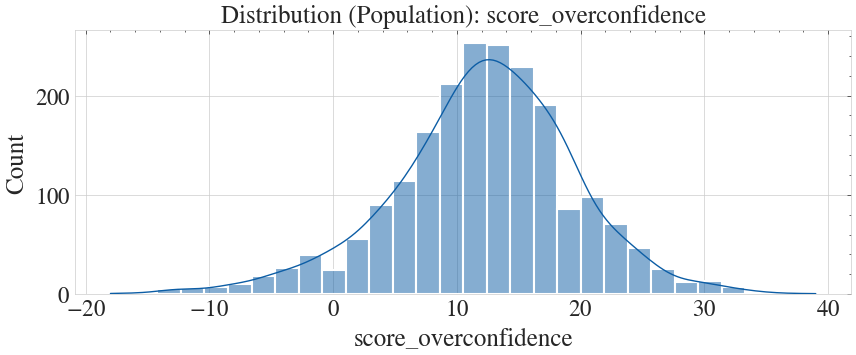

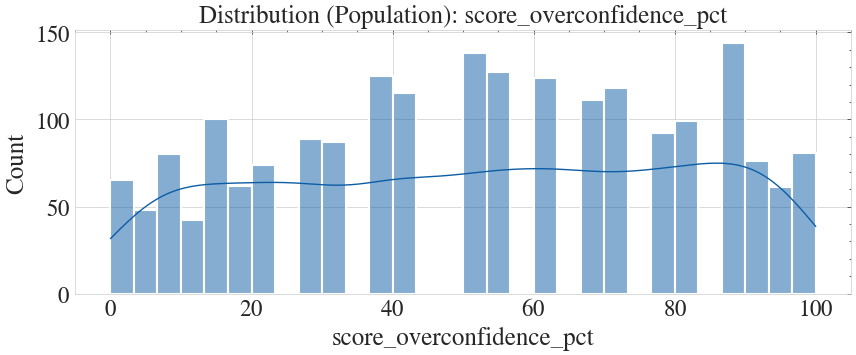

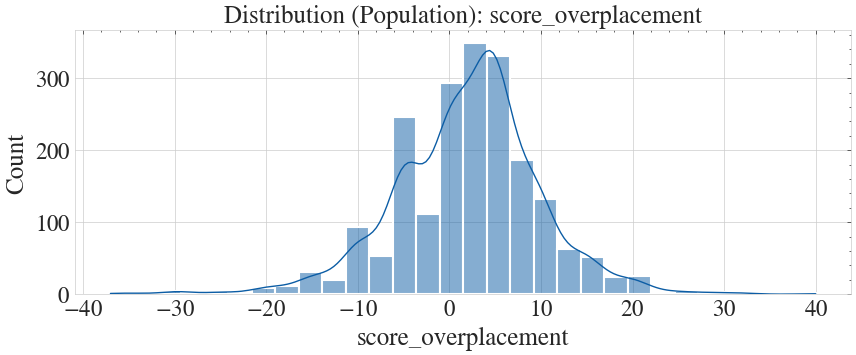

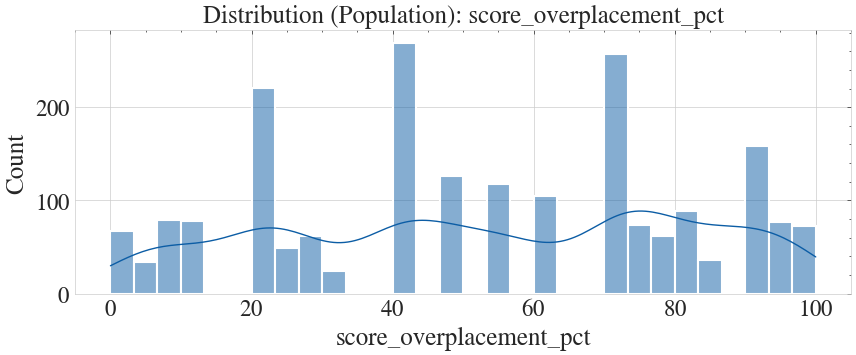

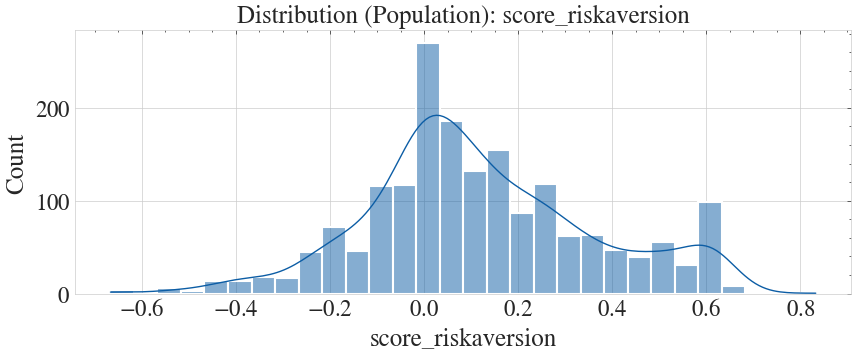

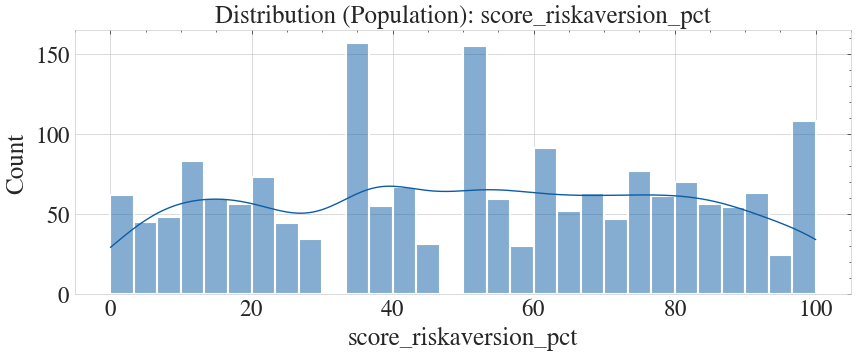

Bias heatmap matrix shape: (1825, 12)


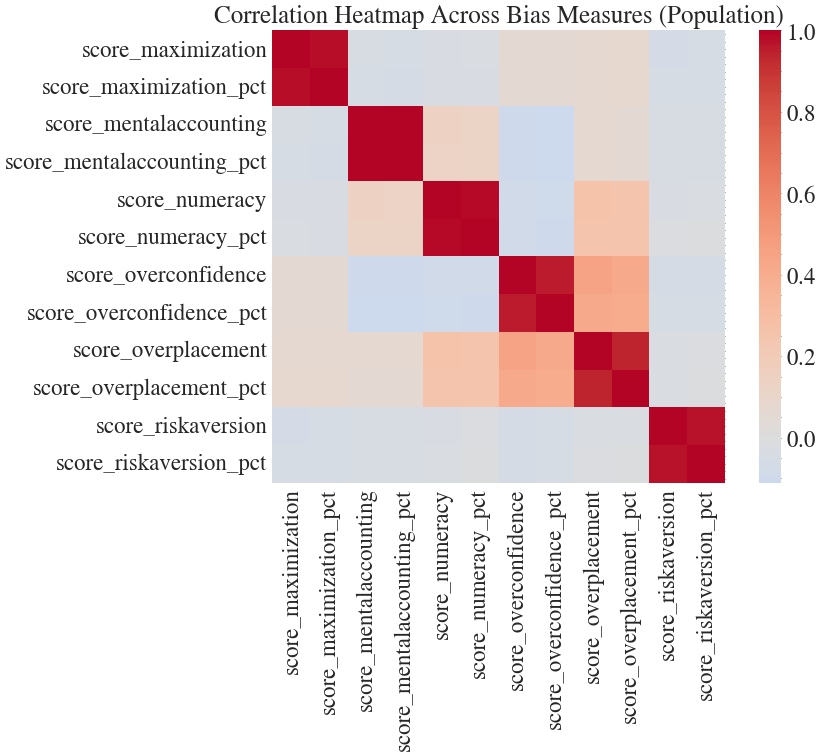

In [14]:
# Find cols that look like "bias proxies" based on keywords in column names.

bias_keywords = [
    "framing", "sunk", "anchor", "anchoring",
    "false", "consensus", "overconfidence", "overplacement",
    "lossaversion", "risk", "numeracy", "mentalaccounting", "maximization"
]

bias_cols = [c for c in persona_df.columns if any(k in c.lower() for k in bias_keywords)]
bias_cols_sorted = sorted(bias_cols)

print("Bias-related columns found:", len(bias_cols_sorted))
print("First 40:", bias_cols_sorted[:40])

# Plot distributions for reasonably-sized columns

for c in bias_cols_sorted:
    vals = persona_df[c].dropna()
    if len(vals) < 100:  
        continue
    plt.figure(figsize=(9, 4))
    sns.histplot(vals, bins=30, kde=True)
    plt.title(f"Distribution (Population): {c}")
    plt.xlabel(c)
    plt.tight_layout()
    plt.show()

# Correlation heatmap across bias proxies with enough coverage

if len(bias_cols_sorted) >= 2:
    bias_df = persona_df[bias_cols_sorted].copy()

    # Drop columns with too many missing values (>40% missing)
    bias_df = bias_df.dropna(axis=1, thresh=int(0.6 * len(bias_df)))

    # Drop rows with any remaining NaNs
    bias_df = bias_df.dropna()

    print("Bias heatmap matrix shape:", bias_df.shape)

    if bias_df.shape[0] >= 50 and bias_df.shape[1] >= 2:
        plt.figure(figsize=(10, 8))
        sns.heatmap(bias_df.corr(), cmap="coolwarm", center=0, square=True)
        plt.title("Correlation Heatmap Across Bias Measures (Population)")
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough complete data for bias correlation heatmap.")


-   Inter-variable relationships + test–retest reliability

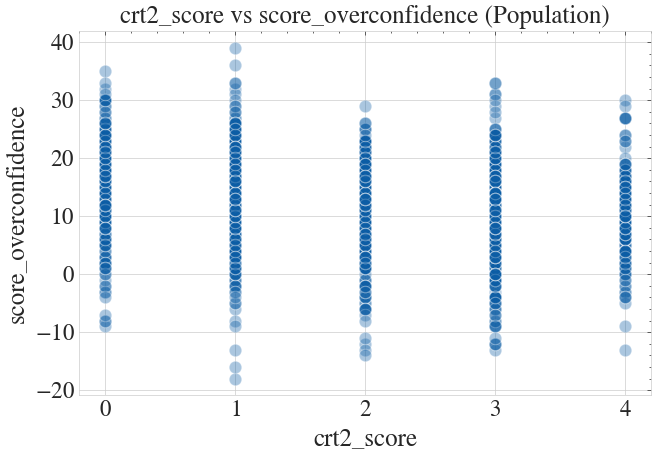

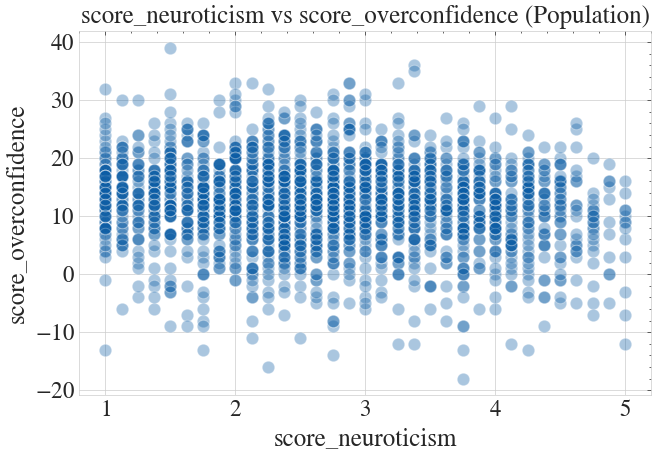

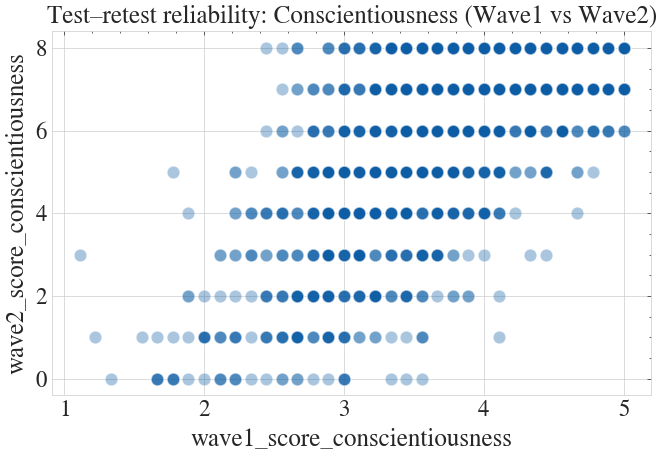

Pearson r: 0.7158613336701295


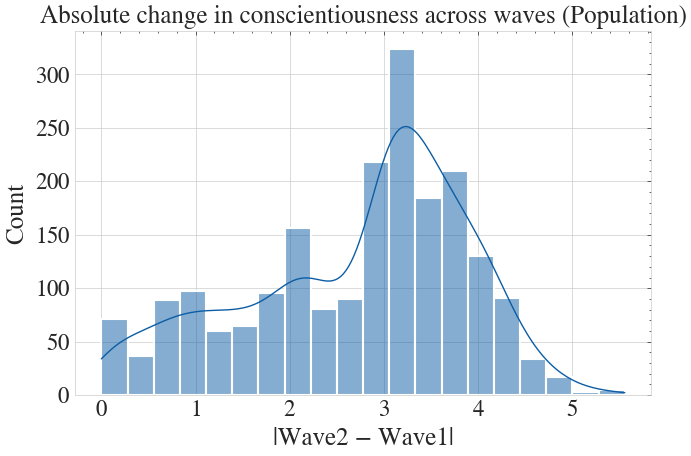

In [15]:
# Example relationships (only plot if columns exist)

pairs_to_plot = [
    ("crt2_score", "score_overconfidence"),
    ("score_neuroticism", "score_overconfidence"),
]

for x, y in pairs_to_plot:
    if x in persona_df.columns and y in persona_df.columns:
        plt.figure(figsize=(7, 5))
        sns.scatterplot(data=persona_df, x=x, y=y, alpha=0.35)
        plt.title(f"{x} vs {y} (Population)")
        plt.tight_layout()
        plt.show()

# Test–retest reliability: conscientiousness across wave1 vs wave2 if both exist
w1 = "wave1_score_conscientiousness"
w2 = "wave2_score_conscientiousness"

if w1 in persona_df.columns and w2 in persona_df.columns:
    tmp = persona_df[[w1, w2]].dropna()

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=tmp, x=w1, y=w2, alpha=0.35)
    plt.title("Test–retest reliability: Conscientiousness (Wave1 vs Wave2)")
    plt.tight_layout()
    plt.show()

    if len(tmp) > 2:
        print("Pearson r:", tmp.corr().iloc[0, 1])

    tmp = tmp.copy()
    tmp["abs_diff"] = (tmp[w2] - tmp[w1]).abs()

    plt.figure(figsize=(7, 5))
    sns.histplot(tmp["abs_diff"], bins=20, kde=True)
    plt.title("Absolute change in conscientiousness across waves (Population)")
    plt.xlabel("|Wave2 − Wave1|")
    plt.tight_layout()
    plt.show()
else:
    print("Wave1/Wave2 conscientiousness columns not both present; skipping reliability plots.")

### 2B. Demographics (Population)

We analyze:
- Age group distribution
- Race distribution
- Household size distribution
- Education distribution
- Income distribution

These are typically categorical and may need ordering for readable plots.

- Clean demographic columns + plots

,Age,Race,Household size,Education level,Income
pid,,,,,
574,18-29,White,4,"Some college, no degree","$100,000 or more"
2001,50-64,White,2,College graduate/some postgrad,"$100,000 or more"
1710,50-64,White,3,Postgraduate,"$50,000-$75,000"
1277,30-49,White,4,Associate's degree,"$50,000-$75,000"
789,50-64,Black,2,High school graduate,"$50,000-$75,000"


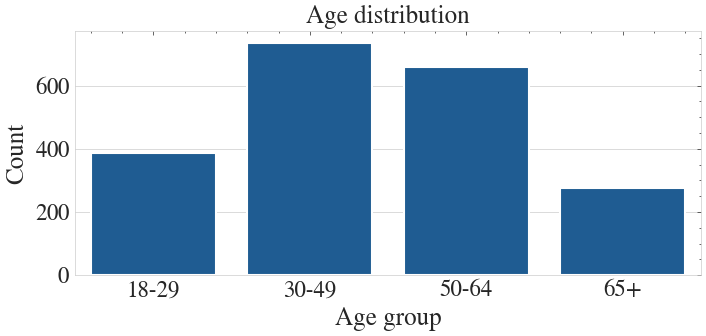

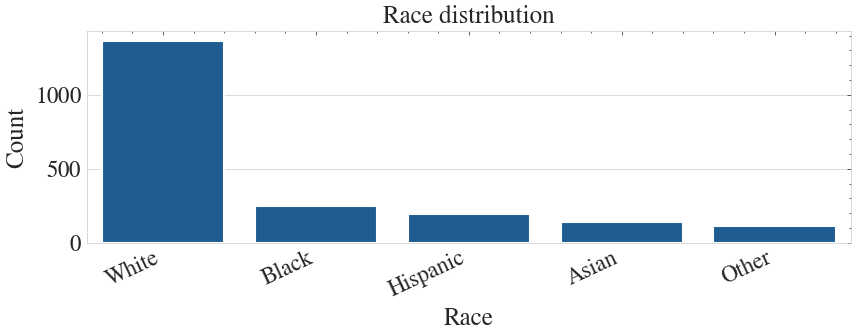

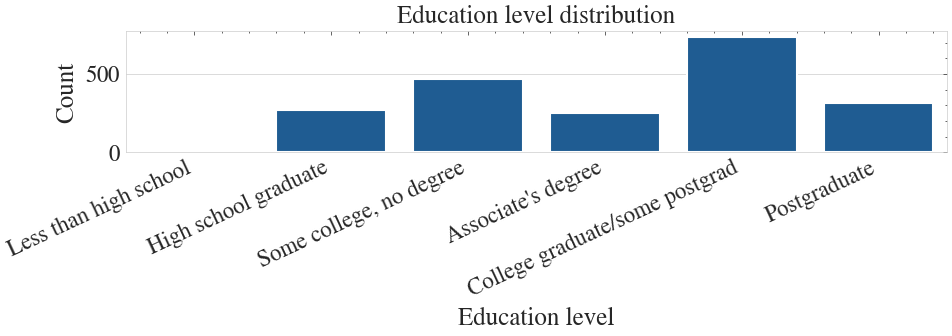

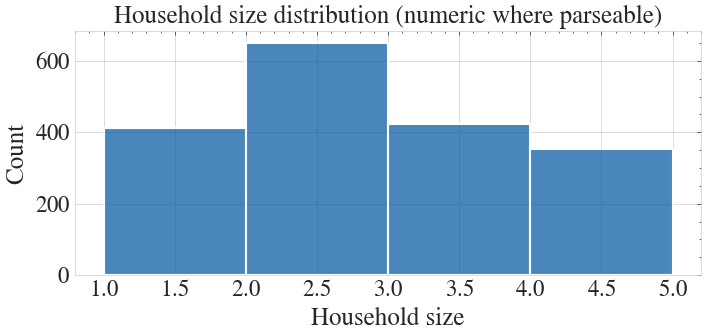

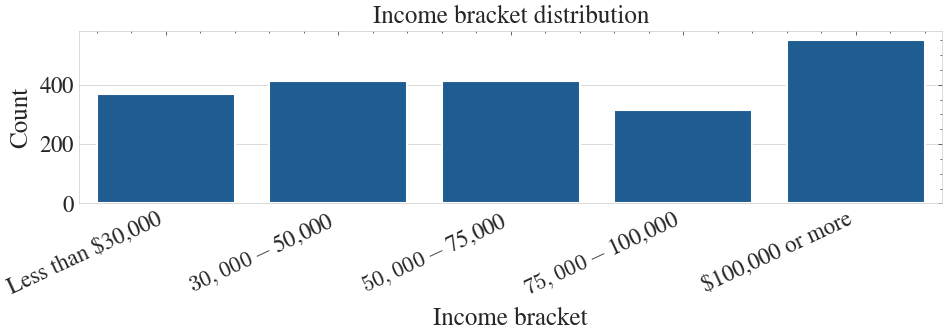

In [16]:
DEM_COLS = ["Age", "Race", "Household size", "Education level", "Income"]
available_dem_cols = [c for c in DEM_COLS if c in persona_df.columns]

dem = persona_df[available_dem_cols].copy()

# Standardize string formatting and set obvious "missing" markers to NaN
for c in dem.columns:
    dem[c] = dem[c].astype(str).str.strip()
    dem.loc[dem[c].isin(["", "None", "nan", "NaN"]), c] = np.nan

display(dem.head())

# ---- Age ----
AGE_ORDER = ["18-29", "30-49", "50-64", "65+"]

if "Age" in dem.columns:
    plt.figure(figsize=(7.5, 3.8))
    sns.countplot(
        data=dem,
        x="Age",
        order=[a for a in AGE_ORDER if a in dem["Age"].dropna().unique()],
    )
    plt.title("Age distribution")
    plt.xlabel("Age group")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# ---- Race ----
if "Race" in dem.columns:
    plt.figure(figsize=(9.0, 3.8))
    order = dem["Race"].value_counts().index
    sns.countplot(data=dem, x="Race", order=order)
    plt.title("Race distribution")
    plt.xlabel("Race")
    plt.ylabel("Count")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

# ---- Education ----
EDU_ORDER = [
    "Less than high school",
    "High school graduate",
    "Some college, no degree",
    "Associate's degree",
    "College graduate/some postgrad",
    "Postgraduate",
]

if "Education level" in dem.columns:
    plt.figure(figsize=(10, 3.8))
    order = [e for e in EDU_ORDER if e in dem["Education level"].dropna().unique()]
    sns.countplot(data=dem, x="Education level", order=order)
    plt.title("Education level distribution")
    plt.xlabel("Education level")
    plt.ylabel("Count")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

# ---- Household size ----
if "Household size" in dem.columns:
    hs_num = pd.to_numeric(dem["Household size"], errors="coerce")
    plt.figure(figsize=(7.5, 3.8))
    sns.histplot(hs_num.dropna(), bins=range(int(hs_num.min()), int(hs_num.max()) + 2))
    plt.title("Household size distribution (numeric where parseable)")
    plt.xlabel("Household size")
    plt.tight_layout()
    plt.show()

# ---- Income ----
INCOME_ORDER = [
    "Less than $30,000",
    "$30,000-$50,000",
    "$50,000-$75,000",
    "$75,000-$100,000",
    "$100,000 or more",
]

if "Income" in dem.columns:
    plt.figure(figsize=(10, 3.8))
    order = [i for i in INCOME_ORDER if i in dem["Income"].dropna().unique()]
    sns.countplot(data=dem, x="Income", order=order)
    plt.title("Income bracket distribution")
    plt.xlabel("Income bracket")
    plt.ylabel("Count")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

### 2D. Cultural & diversity insights

We summarize Religion distribution:
- pie chart for top categories
- table with rank, counts, percent

-   Religion pie + table (clean)

In [17]:
# Clean and summarize Religion column
rel = (
    persona_df["Religion"]
    .astype(str)
    .str.strip()
    .replace({"": np.nan, "None": np.nan, "nan": np.nan, "NaN": np.nan})
)

counts = rel.dropna().value_counts()

top_k = 8
top = counts.head(top_k)
other = counts.iloc[top_k:].sum()

pie_counts = pd.concat([top, pd.Series({"Other": other})]) if other > 0 else top


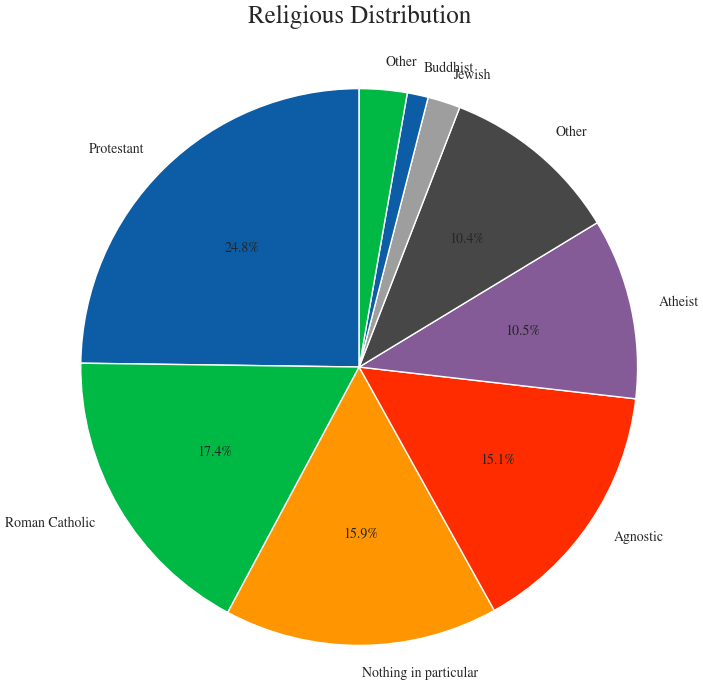

,rank,religion,count,percent
0,1,Protestant,510,24.78
1,2,Roman Catholic,358,17.40
2,3,Nothing in particular,327,15.89
3,4,Agnostic,311,15.11
4,5,Atheist,216,10.50
5,6,Other,215,10.45
6,7,Jewish,39,1.90
7,8,Buddhist,25,1.21
8,9,Other,57,2.77


In [18]:
# Pie chart

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.pie(
    pie_counts.values,
    labels=pie_counts.index,
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 10},
)
ax.set_title("Religious Distribution", pad=14)
ax.axis("equal")
plt.tight_layout()
plt.show()

# Table
religion_table = pie_counts.reset_index()
religion_table.columns = ["religion", "count"]
religion_table["rank"] = np.arange(1, len(religion_table) + 1)
religion_table["percent"] = (religion_table["count"] / religion_table["count"].sum() * 100).round(2)
religion_table = religion_table[["rank", "religion", "count", "percent"]]

display(religion_table)

# 3. Diverse agent selection (KMeans)

Goal:
- Pick a small cohort of representative personas for LLM simulations.
Method:
- Choose a feature set (Big Five + CRT + risk + overplacement).
- Standardize features.
- Cluster into `NUM_AGENTS` clusters.
- Select the person closest to each cluster centroid (a “medoid-like” representative).

Then validate diversity using PCA projection.

- A. Diverse selection

In [19]:
def select_diverse_agents(persona_df: pd.DataFrame, features: list[str], n_agents: int = 20, random_state: int = 42):
    """
    Cluster individuals in standardized feature space into n_agents clusters.
    Select 1 representative per cluster: closest to the cluster center.

    Returns:
      M: original (unscaled) feature dataframe after dropping NaNs
      X: scaled feature matrix
      labels: cluster labels
      selected_ids: list of selected pid indices
    """
    # Keep only features that exist
    features = [f for f in features if f in persona_df.columns]

    # Require complete rows for these features
    M = persona_df[features].dropna()
    if len(M) < n_agents:
        raise ValueError(f"Not enough complete rows ({len(M)}) to pick n_agents={n_agents} with features={features}")

    # Scale features for fair distance calculations
    X = StandardScaler().fit_transform(M)

    # KMeans clustering
    km = KMeans(n_clusters=n_agents, random_state=random_state, n_init="auto")
    labels = km.fit_predict(X)

    # Select the closest sample to each cluster centroid
    selected_ids = []
    for cluster_id in range(n_agents):
        cluster_indices = np.where(labels == cluster_id)[0]
        center = km.cluster_centers_[cluster_id]

        closest_local = cluster_indices[np.argmin(np.linalg.norm(X[cluster_indices] - center, axis=1))]
        selected_ids.append(M.index[closest_local])

    return M, X, labels, selected_ids


NUM_AGENTS = 20
FEATURES = [
    "score_openness",
    "wave1_score_conscientiousness",
    "score_extraversion",
    "score_agreeableness",
    "score_neuroticism",
    "crt2_score",
    "score_riskaversion",
    "score_overplacement",
]

M, X, labels, selected_pids = select_diverse_agents(persona_df, FEATURES, n_agents=NUM_AGENTS, random_state=42)

print("Final no of agents:", len(selected_pids))
print("Example selected agents:", selected_pids[:5])

agents_selected = persona_df.loc[selected_pids].copy()
display(agents_selected.head())

Final no of agents: 20
Example selected agents: ['755', '1549', '1043', '218', '1603']


,Geographic region,Gender,Age,Education level,Race,Citizen of the US,Marital status,Religion,Religious attendance,Political affiliation,...,score_RFS_pct,score_ST-TW_pct,score_depression_pct,score_CNFU-S_pct,score_selfmonitor_pct,score_SCC_pct,score_needforclosure_pct,score_maximization_pct,score_wason_pct,score_dictator_sender_pct
pid,,,,,,,,,,,,,,,,,,,,,
755,"South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC,...",Female,18-29,"Some college, no degree",Black,Yes,Never been married,Protestant,Once a week,Democrat,...,24,39,21,57,33,31,54,34,65,81
1549,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, M...",Female,30-49,"Some college, no degree",White,Yes,Living with a partner,Protestant,Seldom,Democrat,...,41,39,57,33,39,15,42,73,96,81
1043,"West (WA, OR, ID, MT, WY, CA, NV, UT, CO, AZ, NM)",Female,30-49,Associate's degree,White,Yes,Married,Agnostic,Never,Republican,...,71,94,27,38,14,72,59,26,96,81
218,"South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC,...",Male,50-64,College graduate/some postgrad,White,Yes,Never been married,Roman Catholic,A few times a year,Republican,...,65,39,79,43,76,17,85,81,65,81
1603,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, M...",Female,65+,High school graduate,Black,Yes,Married,Other,Once a week,Independent,...,81,48,67,54,0,55,7,2,96,97


- B. Diversity verification via PCA

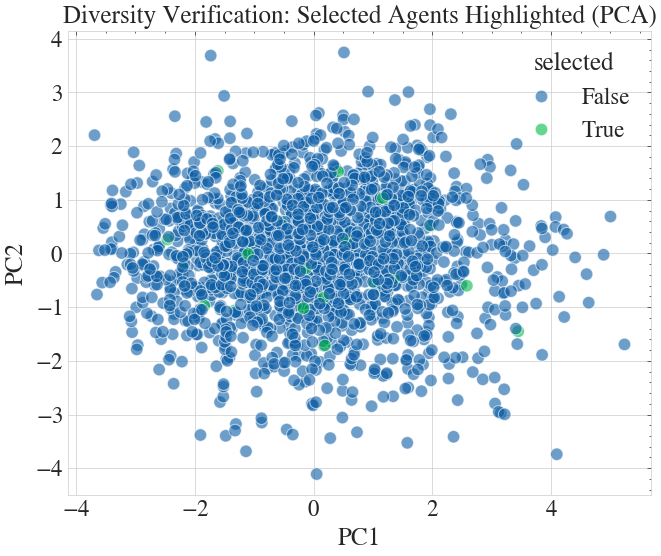

Explained variance ratio: [0.29604661 0.15248848]


In [20]:
# PCA projection in standardized feature space
pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X)

plot_df = pd.DataFrame(XY, index=M.index, columns=["PC1", "PC2"])
plot_df["selected"] = plot_df.index.isin(selected_pids)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="selected", alpha=0.6)
plt.title("Diversity Verification: Selected Agents Highlighted (PCA)")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

In [21]:
import random

male_names = [
    "James","Michael","David","John","Robert","Daniel","Chris","Mark","Paul","Andrew",
    "Steven","Kenneth","George","Edward","Brian","Ronald","Anthony","Kevin","Jason","Jeffery"
]
female_names = [
    "Emma","Olivia","Sophia","Isabella","Ava","Mia","Charlotte","Amelia","Harper","Evelyn",
    "Abigail","Emily","Elizabeth","Mila","Ella","Avery","Sofia","Camila","Scarlett","Victoria"
]

all_names_pool = male_names + female_names
random.seed(42)
random.shuffle(all_names_pool)

if len(all_names_pool) < NUM_AGENTS:
    # Very unlikely here, but safe fallback
    assigned_names = [f"{all_names_pool[i % len(all_names_pool)]}{i}" for i in range(NUM_AGENTS)]
else:
    assigned_names = all_names_pool[:NUM_AGENTS]

agents_selected["name"] = assigned_names

print(f"Assigned names to {len(agents_selected)} agents.")
display(agents_selected[["name"]].head())

agents_selected.to_csv("agents_selected.csv")
print("Saved: agents_selected.csv")

Assigned names to 20 agents.


,name
pid,
755,Andrew
1549,John
1043,Steven
218,Sofia
1603,Mia


Saved: agents_selected.csv


In [22]:
def infer_has_dependents(household_size_value) -> bool:
    """
    Heuristic:
    - If household size == 1 -> no dependents
    - If household size > 1 or contains '+' or 'to' -> assume dependents
    """
    if pd.isna(household_size_value):
        return False

    s = str(household_size_value).strip()

    # Exact "1" means likely living alone
    if s == "1":
        return False

    # Ranges or plus imply more people in household
    if "+" in s or "to" in s:
        return True

    # Try numeric parse
    try:
        n = float(s)
        return n > 1
    except ValueError:
        return False


crt_max_value = persona_df["crt2_score"].max() if "crt2_score" in persona_df.columns else None

json_output = []
for pid, row in agents_selected.iterrows():
    persona_json = {
        "pid": str(pid),
        "name": row.get("name"),
        "big_five": {
            "extraversion": (row.get("score_extraversion_pct") / 100) if pd.notna(row.get("score_extraversion_pct")) else None,
            "agreeableness": (row.get("score_agreeableness_pct") / 100) if pd.notna(row.get("score_agreeableness_pct")) else None,
            "conscientiousness": (row.get("wave1_score_conscientiousness_pct") / 100) if pd.notna(row.get("wave1_score_conscientiousness_pct")) else None,
            "neuroticism": (row.get("score_neuroticism_pct") / 100) if pd.notna(row.get("score_neuroticism_pct")) else None,
            "openness": (row.get("score_openness_pct") / 100) if pd.notna(row.get("score_openness_pct")) else None,
        },
        "crt_score": row.get("crt2_score") if "crt2_score" in agents_selected.columns else None,
        "crt_max": crt_max_value,
        "risk_preference": row.get("score_riskaversion") if "score_riskaversion" in agents_selected.columns else None,
        "has_dependents": infer_has_dependents(row.get("Household size")),
    }
    json_output.append(persona_json)

output_filename = "cohort_personas.json"
with open(output_filename, "w") as f:
    json.dump(json_output, f, indent=2)

print(f"Saved {len(json_output)} personas to {output_filename}")
print("\nFirst 2 personas preview:")
print(json.dumps(json_output[:2], indent=2))

Saved 20 personas to cohort_personas.json

First 2 personas preview:
[
  {
    "pid": "755",
    "name": "Andrew",
    "big_five": {
      "extraversion": 0.33,
      "agreeableness": 0.62,
      "conscientiousness": 0.58,
      "neuroticism": 0.32,
      "openness": 0.53
    },
    "crt_score": 3.0,
    "crt_max": 4.0,
    "risk_preference": 0.611,
    "has_dependents": true
  },
  {
    "pid": "1549",
    "name": "John",
    "big_five": {
      "extraversion": 0.26,
      "agreeableness": 0.73,
      "conscientiousness": 0.37,
      "neuroticism": 0.71,
      "openness": 0.53
    },
    "crt_score": 3.0,
    "crt_max": 4.0,
    "risk_preference": 0.028,
    "has_dependents": true
  }
]


##  Trait-dominance clusters (10 per dominant Big5 trait)

Selection strategy:
- Standardize Big5 scores
- Assign each person to their **dominant Big5 trait** (highest z-score)
- Pick top 10 people per trait → total up to 50


-   Trait dominance selection + PCA visualization

Openness: selected 10
Conscientiousness: selected 10
Extraversion: selected 10
Agreeableness: selected 10
Neuroticism: selected 10


,trait_cluster
pid,
192,Openness
4,Openness
997,Openness
1081,Openness
536,Openness


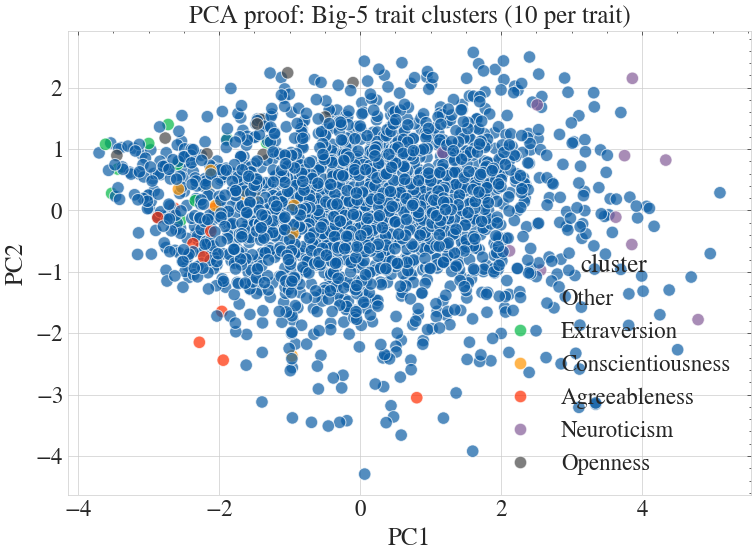

Explained variance ratio: [0.46979607 0.19634499]


In [23]:
BIG5_MAP = {
    "Openness": "score_openness",
    "Conscientiousness": "wave1_score_conscientiousness",
    "Extraversion": "score_extraversion",
    "Agreeableness": "score_agreeableness",
    "Neuroticism": "score_neuroticism",
}

big5_cols = {k: v for k, v in BIG5_MAP.items() if v in persona_df.columns}
trait_names = list(big5_cols.keys())
trait_cols = [big5_cols[t] for t in trait_names]

# Require complete Big5 rows
B = persona_df[trait_cols].dropna().copy()

# Standardize Big5 so dominance comparisons are fair
Z = pd.DataFrame(
    StandardScaler().fit_transform(B),
    index=B.index,
    columns=trait_names,
)

# Dominant trait = argmax across standardized Big5
dominant = Z.idxmax(axis=1)

# Select top 10 per dominant trait
trait_clusters = {}
for t in trait_names:
    group = Z[dominant == t].copy()
    top_ids = group.sort_values(by=t, ascending=False).head(10).index.tolist()
    trait_clusters[t] = top_ids
    print(f"{t}: selected {len(top_ids)}")

# Build labeled dataframe
cluster_rows = []
for t, ids in trait_clusters.items():
    for pid in ids:
        cluster_rows.append({"pid": pid, "trait_cluster": t})

trait_cluster_df = pd.DataFrame(cluster_rows).set_index("pid")
display(trait_cluster_df.head())

# PCA proof in Big5 space
pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(Z.values)

plot_big5 = pd.DataFrame(XY, index=Z.index, columns=["PC1", "PC2"])
plot_big5["cluster"] = "Other"

for t, ids in trait_clusters.items():
    plot_big5.loc[ids, "cluster"] = t

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_big5, x="PC1", y="PC2", hue="cluster", alpha=0.7)
plt.title("PCA proof: Big-5 trait clusters (10 per trait)")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

In [24]:
# "Similar cohort" = k agents closest to a prototype

TARGET_TRAIT = "Neuroticism"   
K_SIMILAR = 10      

In [25]:
# Restrict to people whose dominant trait = TARGET_TRAIT

group_Z = Z[dominant == TARGET_TRAIT].copy()

print(f"Dominant-trait group size for {TARGET_TRAIT}: {len(group_Z):,}")
if len(group_Z) < K_SIMILAR:
    raise ValueError(f"Not enough rows in {TARGET_TRAIT} group to select K={K_SIMILAR}.")

# Define the prototype as the MEDIAN Big5 z-profile (robust to outliers)
prototype = group_Z.median(axis=0)

# Compute Euclidean distance to the prototype for each person
dists = np.linalg.norm(group_Z.values - prototype.values, axis=1)

# Select K closest personas
closest_idx = np.argsort(dists)[:K_SIMILAR]
similar_pids = group_Z.index[closest_idx].tolist()

print(f"Selected {len(similar_pids)} similar agents for trait '{TARGET_TRAIT}'.")
print("Example pids:", similar_pids[:5])

#  Create the similar cohort dataframe
similar_agents = persona_df.loc[similar_pids].copy()
similar_agents["cohort_type"] = "similar"
similar_agents["similarity_target_trait"] = TARGET_TRAIT
display(similar_agents.head())

Dominant-trait group size for Neuroticism: 610
Selected 10 similar agents for trait 'Neuroticism'.
Example pids: ['1651', '1877', '548', '1685', '1691']


,Geographic region,Gender,Age,Education level,Race,Citizen of the US,Marital status,Religion,Religious attendance,Political affiliation,...,score_depression_pct,score_CNFU-S_pct,score_selfmonitor_pct,score_SCC_pct,score_needforclosure_pct,score_maximization_pct,score_wason_pct,score_dictator_sender_pct,cohort_type,similarity_target_trait
pid,,,,,,,,,,,,,,,,,,,,,
1651,"West (WA, OR, ID, MT, WY, CA, NV, UT, CO, AZ, NM)",Female,18-29,"Some college, no degree",Hispanic,Yes,Never been married,Nothing in particular,A few times a year,Democrat,...,85,41,58,28,87,87,65,81,similar,Neuroticism
1877,"West (WA, OR, ID, MT, WY, CA, NV, UT, CO, AZ, NM)",Female,30-49,College graduate/some postgrad,White,Yes,Married,Agnostic,Never,Democrat,...,84,61,46,10,75,87,65,97,similar,Neuroticism
548,"West (WA, OR, ID, MT, WY, CA, NV, UT, CO, AZ, NM)",Male,65+,College graduate/some postgrad,Other,Yes,Married,Roman Catholic,Once a week,Republican,...,45,13,27,69,67,26,65,18,similar,Neuroticism
1685,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, M...",Female,50-64,Associate's degree,White,Yes,Divorced,Roman Catholic,A few times a year,Independent,...,83,28,64,31,46,26,65,81,similar,Neuroticism
1691,"Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, M...",Female,30-49,Associate's degree,White,Yes,Never been married,Roman Catholic,Seldom,Democrat,...,98,23,58,14,85,34,96,81,similar,Neuroticism


In [26]:
BIG5_RAW_COLS = [BIG5_MAP[t] for t in trait_names if BIG5_MAP[t] in persona_df.columns]

# Within-cohort variance in standardized space (Z) is easiest to interpret
similar_Z = Z.loc[similar_pids, trait_names]
print("\nWithin-cohort std (Big5 z-scores) for similar cohort:")
display(similar_Z.std().to_frame("std_z").T)

# Compare against your earlier "diverse cohort" if you have diverse_ids list
if "diverse_ids" in globals():
    diverse_ids_in_Z = [pid for pid in diverse_ids if pid in Z.index]
    diverse_Z = Z.loc[diverse_ids_in_Z, trait_names]
    print("\nWithin-cohort std (Big5 z-scores) for diverse cohort:")
    display(diverse_Z.std().to_frame("std_z").T)


Within-cohort std (Big5 z-scores) for similar cohort:


,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
std_z,0.299257,0.397731,0.237748,0.136735,0.17688


In [27]:
def infer_has_dependents(household_size_value) -> bool:
    """
    Heuristic:
    - Household size == 1 -> no dependents
    - household size > 1 OR contains '+' OR contains 'to' -> dependents
    """
    if pd.isna(household_size_value):
        return False

    s = str(household_size_value).strip()

    if s == "1":
        return False

    if ("+" in s) or ("to" in s):
        return True

    try:
        n = float(s)
        return n > 1
    except ValueError:
        return False


# Compute CRT max if available (matches your earlier JSON format)
crt_max_value = persona_df["crt2_score"].max() if "crt2_score" in persona_df.columns else None

similar_json = []
for pid, row in similar_agents.iterrows():
    similar_json.append({
        "pid": str(pid),
        "cohort_type": "similar",
        "similarity_target_trait": TARGET_TRAIT,
        "big_five": {
            "extraversion": (row.get("score_extraversion_pct") / 100) if pd.notna(row.get("score_extraversion_pct")) else None,
            "agreeableness": (row.get("score_agreeableness_pct") / 100) if pd.notna(row.get("score_agreeableness_pct")) else None,
            "conscientiousness": (row.get("wave1_score_conscientiousness_pct") / 100) if pd.notna(row.get("wave1_score_conscientiousness_pct")) else None,
            "neuroticism": (row.get("score_neuroticism_pct") / 100) if pd.notna(row.get("score_neuroticism_pct")) else None,
            "openness": (row.get("score_openness_pct") / 100) if pd.notna(row.get("score_openness_pct")) else None,
        },
        "crt_score": row.get("crt2_score") if "crt2_score" in similar_agents.columns else None,
        "crt_max": crt_max_value,
        "risk_preference": row.get("score_riskaversion") if "score_riskaversion" in similar_agents.columns else None,
        "has_dependents": infer_has_dependents(row.get("Household size")),
    })

out_name = f"cohort_similar_{TARGET_TRAIT.lower()}.json"
with open(out_name, "w") as f:
    json.dump(similar_json, f, indent=2)

print(f"Saved similar cohort JSON: {out_name}")
print("\nPreview (first 2):")
print(json.dumps(similar_json[:2], indent=2))

Saved similar cohort JSON: cohort_similar_neuroticism.json

Preview (first 2):
[
  {
    "pid": "1651",
    "cohort_type": "similar",
    "similarity_target_trait": "Neuroticism",
    "big_five": {
      "extraversion": 0.22,
      "agreeableness": 0.32,
      "conscientiousness": 0.21,
      "neuroticism": 0.83,
      "openness": 0.31
    },
    "crt_score": 2.0,
    "crt_max": 4.0,
    "risk_preference": 0.322,
    "has_dependents": false
  },
  {
    "pid": "1877",
    "cohort_type": "similar",
    "similarity_target_trait": "Neuroticism",
    "big_five": {
      "extraversion": 0.37,
      "agreeableness": 0.27,
      "conscientiousness": 0.17,
      "neuroticism": 0.83,
      "openness": 0.41
    },
    "crt_score": 4.0,
    "crt_max": 4.0,
    "risk_preference": 0.178,
    "has_dependents": false
  }
]


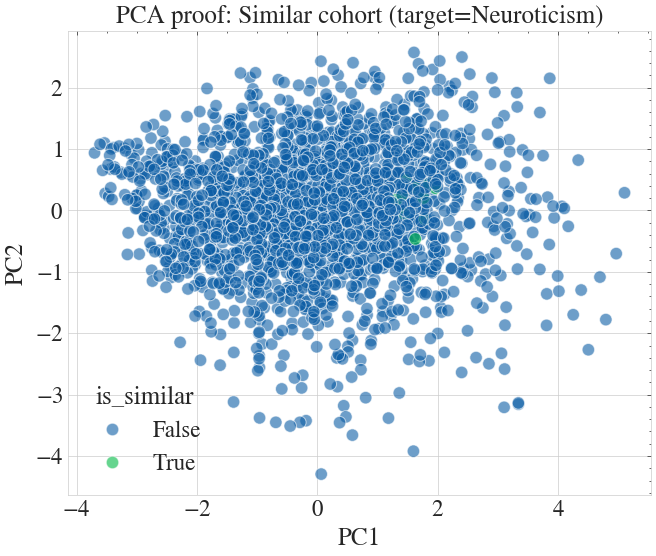

Explained variance ratio: [0.46979607 0.19634499]


In [28]:
# Similar cohort highlighted in PCA plot

pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(Z.values)

plot_df = pd.DataFrame(XY, index=Z.index, columns=["PC1", "PC2"])
plot_df["is_similar"] = plot_df.index.isin(similar_pids)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="is_similar", alpha=0.6)
plt.title(f"PCA proof: Similar cohort (target={TARGET_TRAIT})")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)